# Protein EDA (Pfam family dataset)

This notebook loads the processed UniProt+Pfam dataset and performs:
- sanity checks (missing values, duplicates, length consistency)
- label distribution summaries
- basic sequence statistics
- plots saved under `reports/figures/`
- EDA summary saved under `reports/`

In [1]:
from pathlib import Path
import json
import platform
import sys

import pandas as pd
import numpy as np
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

## Paths + config + load dataset

In [2]:
ROOT = Path.cwd().parents[0]
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
CONFIGS = ROOT / "configs"

for p in [REPORTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

cfg_path = CONFIGS / "config.yaml"
with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

N_FAM = int(cfg["protein"]["n_families"])
PER_FAM = int(cfg["protein"]["per_family"])

in_csv = PROCESSED / f"protein_uniprot_pfam_top{N_FAM}_per{PER_FAM}.csv"
assert in_csv.exists(), f"Missing processed dataset: {in_csv}"

df = pd.read_csv(in_csv)
df.shape, df.head(3)

((2293, 4),
   accession                                           sequence  length  \
 0    Q96RD1  MRNHTEITEFILLGLTDDPNFQVVIFVFLLITYMLSITGNLTLITI...     312   
 1    Q9H210  MRQINQTQVTEFLLLGLSDGPHTEQLLFIVLLGVYLVTVLGNLLLI...     308   
 2    Q8NGZ3  MNHSVVTEFIILGLTKKPELQGIIFLFFLIVYLVAFLGNMLIIIAK...     307   
 
     family  
 0  PF13853  
 1  PF13853  
 2  PF13853  )

## Basic validation checks

In [3]:
# required columns
required = ["accession", "sequence", "length", "family"]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

# missing values
na_counts = df[required].isna().sum()
na_counts

accession    0
sequence     0
length       0
family       0
dtype: int64

In [4]:
# duplicates (should be clean from ingestion)
dup_accessions = int(df["accession"].duplicated().sum())
dup_seq_family = int(df.duplicated(subset=["sequence", "family"]).sum())

dup_accessions, dup_seq_family

(0, 0)

In [5]:
# length consistency
seq_len = df["sequence"].str.len()
n_mismatch = int((seq_len != df["length"]).sum())

n_mismatch, seq_len.describe()

(0,
 count    2293.000000
 mean      394.406891
 std       196.080158
 min        73.000000
 25%       292.000000
 50%       346.000000
 75%       500.000000
 max      1023.000000
 Name: sequence, dtype: float64)

## Label distribution + dataset size

In [6]:
n_rows = int(df.shape[0])
n_families = int(df["family"].nunique())
family_counts = df["family"].value_counts()

n_rows, n_families, family_counts

(2293,
 10,
 family
 PF13853    400
 PF01352    350
 PF07686    309
 PF00001    287
 PF00069    203
 PF00096    194
 PF00046    187
 PF00071    125
 PF00076    121
 PF12796    117
 Name: count, dtype: int64)

## Length statistics

In [7]:
df["length"].describe()

count    2293.000000
mean      394.406891
std       196.080158
min        73.000000
25%       292.000000
50%       346.000000
75%       500.000000
max      1023.000000
Name: length, dtype: float64

## Sequence alphabet sanity

Counts non-standard amino-acid letters per sequence.
(Valid set = 20 canonical amino acids)

In [8]:
valid_aas = set(list("ACDEFGHIKLMNPQRSTVWY"))

def count_nonstandard(seq: str) -> int:
    return sum(1 for ch in seq if ch not in valid_aas)

df["nonstandard_aa_count"] = df["sequence"].astype(str).apply(count_nonstandard)

df["nonstandard_aa_count"].describe(), int((df["nonstandard_aa_count"] > 0).sum())

(count    2293.0
 mean        0.0
 std         0.0
 min         0.0
 25%         0.0
 50%         0.0
 75%         0.0
 max         0.0
 Name: nonstandard_aa_count, dtype: float64,
 0)

## Plots (saved to `reports/figures/`)

1) family counts  
2) length histogram  
3) length by family (boxplot)  
4) non-standard AA count distribution (optional sanity plot)

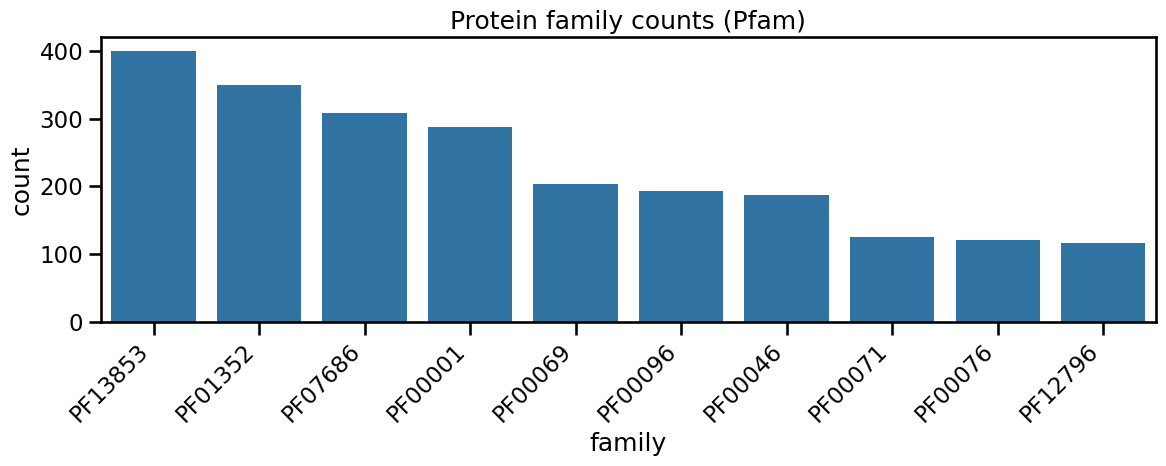

In [9]:
sns.set_context("talk")
order = df["family"].value_counts().index.tolist()

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="family", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Protein family counts (Pfam)")
plt.tight_layout()
plt.savefig(FIGURES / "protein_family_counts.png", dpi=200)
plt.show()

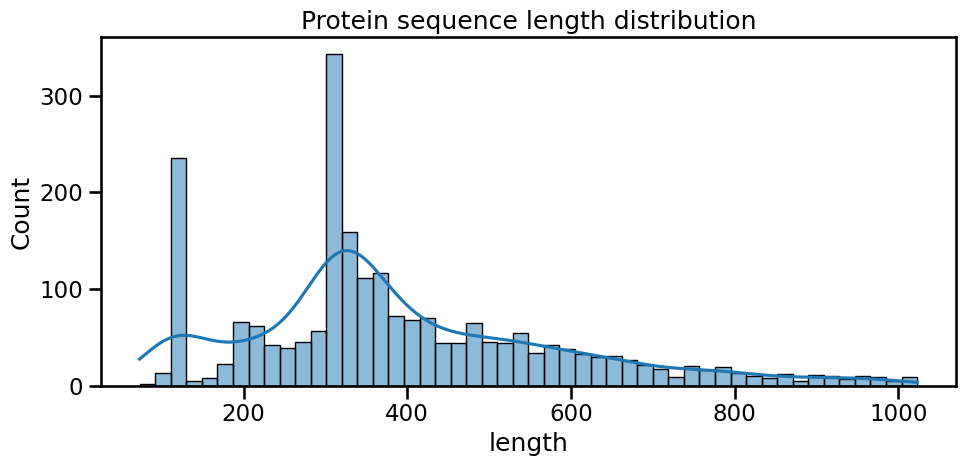

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["length"], bins=50, kde=True)
plt.title("Protein sequence length distribution")
plt.tight_layout()
plt.savefig(FIGURES / "protein_length_hist.png", dpi=200)
plt.show()

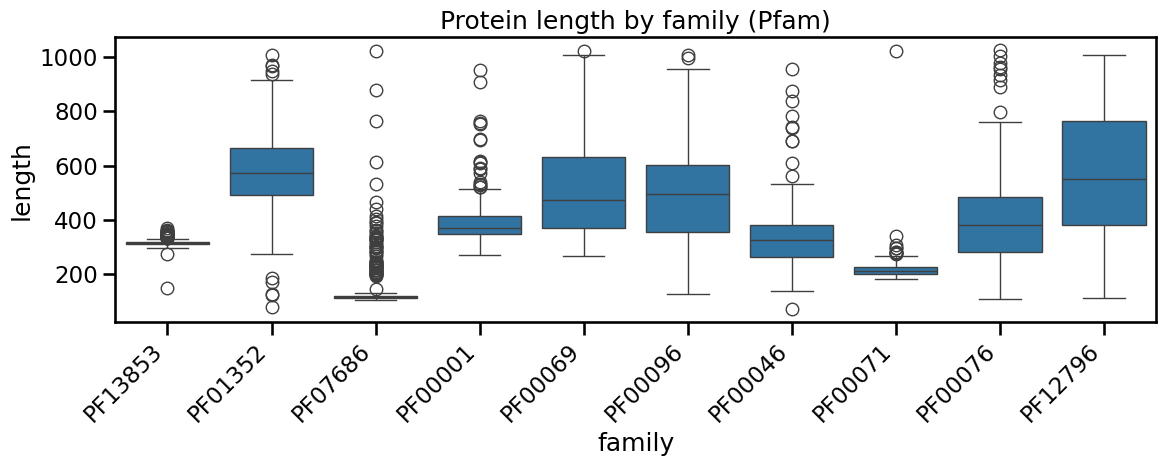

In [11]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="family", y="length", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Protein length by family (Pfam)")
plt.tight_layout()
plt.savefig(FIGURES / "protein_length_by_family.png", dpi=200)
plt.show()

In [12]:
if (df["nonstandard_aa_count"] > 0).any():
    plt.figure(figsize=(10, 4))
    sns.histplot(df["nonstandard_aa_count"], bins=30)
    plt.title("Non-standard amino acid count per sequence")
    plt.tight_layout()
    plt.savefig(FIGURES / "protein_nonstandard_aa_hist.png", dpi=200)
    plt.show()
else:
    print("All sequences contain only canonical amino acids (A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y). Skipping nonstandard AA plot.")

All sequences contain only canonical amino acids (A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y). Skipping nonstandard AA plot.


## Save EDA summary (`reports/protein_eda_summary.json`)

In [13]:
# figures dict (only include nonstandard plot if it was created)
figures = {
    "protein_family_counts": str(FIGURES / "protein_family_counts.png"),
    "protein_length_hist": str(FIGURES / "protein_length_hist.png"),
    "protein_length_by_family": str(FIGURES / "protein_length_by_family.png"),
}

nonstd_fig = FIGURES / "protein_nonstandard_aa_hist.png"
if nonstd_fig.exists():
    figures["protein_nonstandard_aa_hist"] = str(nonstd_fig)

eda_summary = {
    "dataset_path": str(in_csv),
    "n_rows": int(df.shape[0]),
    "n_families": int(df["family"].nunique()),
    "family_counts": df["family"].value_counts().to_dict(),
    "length_min": int(df["length"].min()),
    "length_median": float(df["length"].median()),
    "length_max": int(df["length"].max()),
    "n_mismatch_len": int((df["sequence"].str.len() != df["length"]).sum()),
    "n_with_nonstandard_aa": int((df["nonstandard_aa_count"] > 0).sum()),
    "duplicates": {
        "dup_accessions": int(df["accession"].duplicated().sum()),
        "dup_sequence_family": int(df.duplicated(subset=["sequence", "family"]).sum()),
    },
    "env": {
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
    "figures": figures,
}

eda_path = REPORTS / "protein_eda_summary.json"
with open(eda_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

eda_path

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_eda_summary.json')